# Analysis

The goal of this notebook is to get a rough understanding of the data we are presented with.
We do this by
1. Loading all 40 sound files
2. Getting some basic information about each file
3. Taking a look at that information visually
4. Filtering out some outliers
5. And plotting all the spectograms

First of course we need to load some libraries:

In [ ]:
import matplotlib.pyplot as plt # Plots the diagrams
import os                       # OS memory interface
import numpy as np              # Calculates statistics for sound files
import soundfile as sf          # Loads sound files from memory

Let's declare some usefull constants:

In [3]:
DATA_DIR = "./data"
WAVE_FORM_DIR = "./wave_forms"

This helper function will load the signal for a specified file from memory:

In [5]:
def get_signal(path: str) -> np.ndarray:
    signal, sample_rate = sf.read(f"{DATA_DIR}/{path}")
    return signal

Now we prepare some mixed stuff:
- Get a list of all sound files in `wav_file_path`
- Prepare arrays for statistics (`means`, ...)
- Setup a blacklist, which is later used to filter out data which is not interesting to us but dominates the analysis
- Declare `analyze_data` which will go through all files and calculate their statistics
- Call `analyze_data` while *ignoring* the blacklist

In [6]:
wav_file_paths = sorted(os.listdir(DATA_DIR))

time_stamps = []
means = []
maxs = []
varis = []
noises = []

BLACKLIST = [
    0,
    1,
    14,
    15,
    16,
    37,
    38,
    39,
    40,
]

def analyze_data(blacklist_enabled: bool = False):
    for i, wav_file_path in enumerate(wav_file_paths):
        if i in BLACKLIST and blacklist_enabled:
            continue
        signal = get_signal(wav_file_path)
        time_stamps.append(wav_file_path.split("_")[-1].split(".")[0])
        means.append(np.mean(np.abs(signal)))
        maxs.append(np.max(np.abs(signal)))
        varis.append(np.var(np.abs(signal)))

analyze_data(False)

We proceed to draw all statistics gathered while also indicating the timestamps where different events happened (`draw_it`):

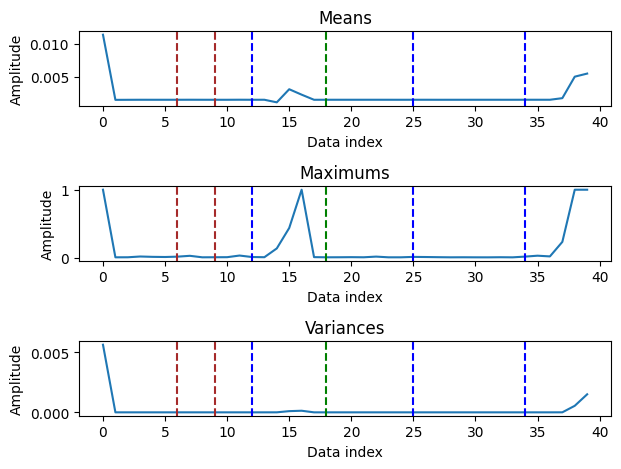

In [5]:
def draw_it(ax, title: str, xlabel: str = "", ylabel: str = ""):
    ax.set_title(title)
    ax.axvline(time_stamps.index("093000"), linestyle="--", label="Ducks", color="brown")
    ax.axvline(time_stamps.index("100000"), linestyle="--", label="Ducks again", color="brown")
    ax.axvline(time_stamps.index("103000"), linestyle="--", label="Otter close", color="blue")
    ax.axvline(time_stamps.index("113000"), linestyle="--", label="Rain", color="green")
    ax.axvline(time_stamps.index("124000"), linestyle="--", label="Otter approaches", color="blue")
    ax.axvline(time_stamps.index("141000"), linestyle="--", label="Otter goes away", color="blue")
    #ax.axvline(time_stamps.index("145000"), linestyle="--", label="Otter approaches", color="blue")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.legend()
    #ax.show()

fig, axs = plt.subplots(3)

axs[0].plot(means)
draw_it(axs[0], "Means", xlabel="Data index", ylabel="Amplitude")

axs[1].plot(maxs)
draw_it(axs[1], "Maximums", xlabel="Data index", ylabel="Amplitude")

axs[2].plot(varis)
draw_it(axs[2], "Variances", xlabel="Data index", ylabel="Amplitude")

plt.tight_layout()

After the data is being dominated by some datapoints we don't care about, let's run the same analysis with the blacklist enabled:

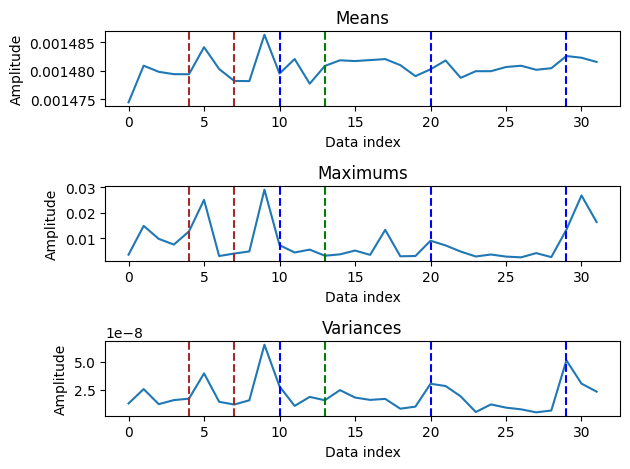

In [6]:
# Reload analysis with new data
time_stamps = []
means = []
maxs = []
varis = []
noises = []
analyze_data(True)

# Redraw
fig, axs = plt.subplots(3)
axs[0].plot(means)
draw_it(axs[0], "Means", xlabel="Data index", ylabel="Amplitude")
axs[1].plot(maxs)
draw_it(axs[1], "Maximums", xlabel="Data index", ylabel="Amplitude")
axs[2].plot(varis)
draw_it(axs[2], "Variances", xlabel="Data index", ylabel="Amplitude")
plt.tight_layout()

And finally draw all spectograms for all wave files:

Generating wave file: 083000 #0/40


/home/arian/Documents/Master/03-IMAA-IMS/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


Generating wave file: 084000 #1/40
Generating wave file: 085000 #2/40
Generating wave file: 090000 #3/40
Generating wave file: 091000 #4/40
Generating wave file: 092000 #5/40
Generating wave file: 093000 #6/40
Generating wave file: 094000 #7/40
Generating wave file: 095000 #8/40
Generating wave file: 100000 #9/40
Generating wave file: 101000 #10/40
Generating wave file: 102000 #11/40
Generating wave file: 103000 #12/40
Generating wave file: 104000 #13/40
Generating wave file: 105000 #14/40
Generating wave file: 110644 #15/40
Generating wave file: 111000 #16/40
Generating wave file: 112000 #17/40
Generating wave file: 113000 #18/40
Generating wave file: 114000 #19/40
Generating wave file: 115000 #20/40
Generating wave file: 120000 #21/40
Generating wave file: 121000 #22/40
Generating wave file: 122000 #23/40
Generating wave file: 123000 #24/40
Generating wave file: 124000 #25/40
Generating wave file: 125000 #26/40
Generating wave file: 130000 #27/40
Generating wave file: 131000 #28/40
G

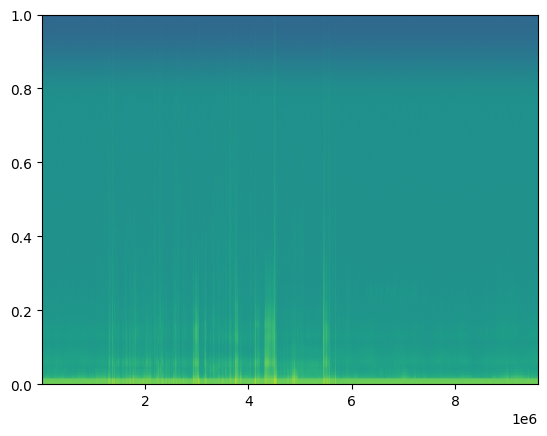

In [7]:
for i, wav_file_path in enumerate(wav_file_paths):
    time_stamp = wav_file_path.split("_")[-1].split(".")[0]
    print(f"Generating wave file: {time_stamp} #{i}/{len(wav_file_paths)}")
    signal = get_signal(wav_file_path)
    plt.specgram(signal)
    plt.savefig(f"{WAVE_FORM_DIR}/{time_stamp}.png")